In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/keloggscornflakes/top-ai-companies-in-us-israel-military-support/Support File.xlsx
/kaggle/input/datasets/keloggscornflakes/top-ai-companies-in-us-israel-military-support/Top AI Companies in US-Israel Military Support (till 2026).xlsx


# How and What AI companies are playing an important role in US-Israel military operations?


Preparing the dataset:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/kaggle/input/datasets/keloggscornflakes/top-ai-companies-in-us-israel-military-support/Top AI Companies in US-Israel Military Support (till 2026).xlsx")

Exploring key findings:

In [3]:
df.shape

(8, 9)

In [4]:
df.head(8)

,Company,Primary AI/Tech Role,Key Contracts/Partnerships (US/Israel),Current Contract Value ($B),Duration of Contract,Project / Mission Name,Primary Goal,Recent Military Support Examples,Sources
0,Palantir,"AI data analytics, targeting (Maven)",US: Project Maven (DoD); Israel: Strategic par...,Up to $10B (Army ESA ceiling); ~$1.3B (Maven c...,2025–2035 (10 years),Project Maven (US DoD); Strategic MoD Partners...,Accelerate intelligence analysis & target sele...,Iran targeting prioritization; Gaza intel fusion,"Breaking Defense, DefenseScoop, Reuters"
1,Microsoft,"Cloud/AI infra (Azure), models (GPT)",US: Army software; Israel: MoD/Azure contract,Up to $10B+ (various US deals); ~$0.133B (Isra...,"Long-term (2025–2035 US); 2021 onward (Israel,...",Azure for IDF Unit 8200 surveillance; Broad Do...,Provide secure cloud & AI infrastructure,Gaza surveillance & data processing; Iran ops ...,"Microsoft blog, Guardian, BDS Movement"
2,Google/Alphabet,Cloud/AI (Gemini/Vertex),US: Joint Warfighting Cloud; Israel: Project N...,$1.2B total (Nimbus shared with Amazon),2021 onward (initial 7 years + extensions),Project Nimbus (Israel gov/military cloud/AI),Deliver cloud computing & AI processing tools,Gaza facial recognition & object tracking; Ira...,"Wikipedia, TIME, +972 Magazine"
3,Amazon (AWS),Cloud infra for intel,US: CIA/Spec Ops; Israel: Project Nimbus,$1.2B total (Nimbus shared with Google),2021 onward (initial 7 years + extensions),Project Nimbus (Israel gov/military cloud/AI),Supply scalable cloud storage & compute,Gaza intel storage & processing; Iran-targeted...,Guardian +972 Magazine
4,Anthropic (Claude),LLMs for targeting/simulations,US: DoD/Palantir integration (pre-ban); Resume...,"Up to ~$0.2B (2025 Pentagon ceiling, phased ou...",2025 (cancelled/phased out 2026),"Project Maven Smart System (via Palantir, pre-...",Enable large-context intelligence summarization,Iran target prioritization (pre-ban via Maven),"Mayer Brown, CNN, CNBC"
5,OpenAI,LLMs for intel/planning,US: DoD prototype (post-Anthropic shift),Up to ~$0.2B (2025–2026 Pentagon agreements),2025–2026,DoD classified prototypes; Post-Anthropic gap ...,"Support planning, simulation & decision aids",Iran operational planning (post-ban prototypes),"OpenAI, NYT, CNBC"
6,Anduril,Autonomous drones/AI defense,US: DoD UAV; Israel: Trials/partnerships,Over $1B (cumulative wins); ~$2B+ revenue fore...,2025 onward (ongoing),Replicator program (US DoD drone swarms); CCA ...,Build autonomous drone & defense systems,Gaza border surveillance; Iran drone swarm sup...,"Anduril, The Information"
7,Shield AI,AI drones (Hivemind/Nova),US: USAF/DoD; Israel: Orders,"~0.267–0.3B (2025 revenue); e.g., $0.198B (Coa...",2025 onward (multi-year),Replicator program (drone swarms); V-BAT ISR c...,Deliver AI-piloted autonomous drones,Gaza indoor ISR; Iran drone operations debut,Fortune


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 9 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Company                                 8 non-null      object
 1   Primary AI/Tech Role                    8 non-null      object
 2   Key Contracts/Partnerships (US/Israel)  8 non-null      object
 3   Current Contract Value ($B)             8 non-null      object
 4   Duration of Contract                    8 non-null      object
 5   Project / Mission Name                  8 non-null      object
 6   Primary Goal                            8 non-null      object
 7   Recent Military Support Examples        8 non-null      object
 8   Sources                                 8 non-null      object
dtypes: object(9)
memory usage: 708.0+ bytes


In [6]:
#cleaning data: datatype conversion
#NOTE: Anduril , sheild AI includes 'revenue' as they generate revenue from military supports

# Option 1: Show full content of all columns (recommended for small datasets)
pd.set_option('display.max_colwidth', None)
df['Current Contract Value ($B)']

import re
# Step 1: Create a numeric version of the column
def extract_max_value(s):
    if pd.isna(s):
        return None
    s = re.sub(r'\b(19|20)\d{2}(?:–\d{4})?\b', '', str(s))
    nums = re.findall(r'\d+\.?\d*', s)
    if not nums:
        return None
    return max(float(n) for n in nums)

df['Numeric Value'] = df['Current Contract Value ($B)'].apply(extract_max_value)

df['Numeric Value']


0    10.0
1    10.0
2     1.2
3     1.2
4     0.2
5     0.2
6     2.0
7     0.3
Name: Numeric Value, dtype: float64

In [7]:
#how high the value is in %:
max_val = df['Numeric Value'].max()
perc = (df['Numeric Value']/ max_val)*100
perc

0    100.0
1    100.0
2     12.0
3     12.0
4      2.0
5      2.0
6     20.0
7      3.0
Name: Numeric Value, dtype: float64

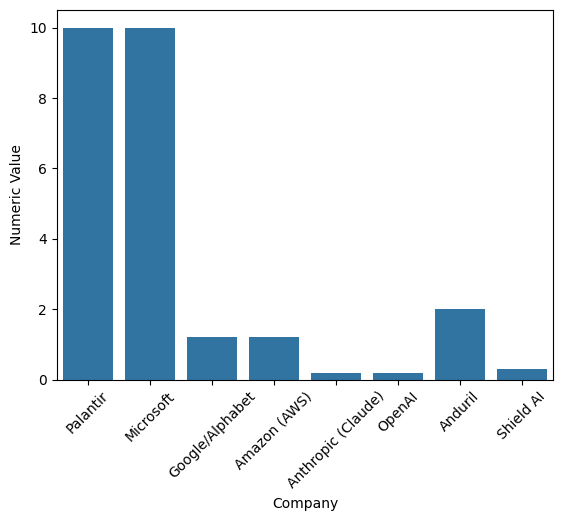

In [8]:
#key visualization for compan's highest contract value (recent):
sns.barplot( x=df['Company'] , y=df['Numeric Value'])
plt.xticks( rotation= 45)
plt.show()

**key finding:**
- The highest Current Contract Values are of: **Palantir** and **Microsoft** , of 10 Billion worth.

In [9]:
df['Duration of Contract']

0                                        2025–2035 (10 years)
1    Long-term (2025–2035 US); 2021 onward (Israel, extended)
2                  2021 onward (initial 7 years + extensions)
3                  2021 onward (initial 7 years + extensions)
4                            2025 (cancelled/phased out 2026)
5                                                   2025–2026
6                                       2025 onward (ongoing)
7                                    2025 onward (multi-year)
Name: Duration of Contract, dtype: object

***Note:*** 
Contract duration of **Palantir** is *10 years* (2025 - 2035)

In [10]:
def extract_start_year(s):
    if pd.isna(s):
        return None
    s = str(s)
    # Find first valid year
    match = re.search(r'\b(20\d{2})\b', s)
    return int(match.group(1)) if match else None


df['start'] = df['Duration of Contract'].apply(extract_start_year)

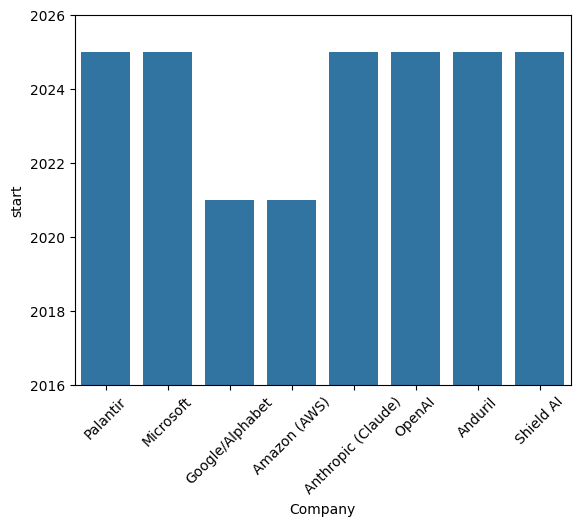

In [11]:
#key visualization for contract durations of each company:
sns.barplot( x=df['Company'] , y=df['start'])
plt.ylim(2016,2026)
plt.xticks( rotation = 45)
plt.show()

**key findings:**
- Companies are generally contracted for a **long-term duration**.
- **Anthropic** was banned after *1 year of contract in **Project Maven*** while **OpenAI** *filled this gap* (should be investigated further).

In [12]:
df.head(8)

,Company,Primary AI/Tech Role,Key Contracts/Partnerships (US/Israel),Current Contract Value ($B),Duration of Contract,Project / Mission Name,Primary Goal,Recent Military Support Examples,Sources,Numeric Value,start
0,Palantir,"AI data analytics, targeting (Maven)",US: Project Maven (DoD); Israel: Strategic partnership,Up to $10B (Army ESA ceiling); ~$1.3B (Maven ceiling),2025–2035 (10 years),Project Maven (US DoD); Strategic MoD Partnership (Israel),Accelerate intelligence analysis & target selection,Iran targeting prioritization; Gaza intel fusion,"Breaking Defense, DefenseScoop, Reuters",10.0,2025
1,Microsoft,"Cloud/AI infra (Azure), models (GPT)",US: Army software; Israel: MoD/Azure contract,Up to $10B+ (various US deals); ~$0.133B (Israel MoD),"Long-term (2025–2035 US); 2021 onward (Israel, extended)",Azure for IDF Unit 8200 surveillance; Broad DoD cloud contracts,Provide secure cloud & AI infrastructure,Gaza surveillance & data processing; Iran ops support,"Microsoft blog, Guardian, BDS Movement",10.0,2025
2,Google/Alphabet,Cloud/AI (Gemini/Vertex),US: Joint Warfighting Cloud; Israel: Project Nimbus,$1.2B total (Nimbus shared with Amazon),2021 onward (initial 7 years + extensions),Project Nimbus (Israel gov/military cloud/AI),Deliver cloud computing & AI processing tools,Gaza facial recognition & object tracking; Iran simulations,"Wikipedia, TIME, +972 Magazine",1.2,2021
3,Amazon (AWS),Cloud infra for intel,US: CIA/Spec Ops; Israel: Project Nimbus,$1.2B total (Nimbus shared with Google),2021 onward (initial 7 years + extensions),Project Nimbus (Israel gov/military cloud/AI),Supply scalable cloud storage & compute,Gaza intel storage & processing; Iran-targeted cloud infra,Guardian +972 Magazine,1.2,2021
4,Anthropic (Claude),LLMs for targeting/simulations,US: DoD/Palantir integration (pre-ban); Resumed talks,"Up to ~$0.2B (2025 Pentagon ceiling, phased out/cancelled)",2025 (cancelled/phased out 2026),"Project Maven Smart System (via Palantir, pre-ban)",Enable large-context intelligence summarization,Iran target prioritization (pre-ban via Maven),"Mayer Brown, CNN, CNBC",0.2,2025
5,OpenAI,LLMs for intel/planning,US: DoD prototype (post-Anthropic shift),Up to ~$0.2B (2025–2026 Pentagon agreements),2025–2026,DoD classified prototypes; Post-Anthropic gap filler (Maven-related),"Support planning, simulation & decision aids",Iran operational planning (post-ban prototypes),"OpenAI, NYT, CNBC",0.2,2025
6,Anduril,Autonomous drones/AI defense,US: DoD UAV; Israel: Trials/partnerships,Over $1B (cumulative wins); ~$2B+ revenue forecast (2025),2025 onward (ongoing),Replicator program (US DoD drone swarms); CCA autonomy (Air Force),Build autonomous drone & defense systems,Gaza border surveillance; Iran drone swarm support,"Anduril, The Information",2.0,2025
7,Shield AI,AI drones (Hivemind/Nova),US: USAF/DoD; Israel: Orders,"~0.267–0.3B (2025 revenue); e.g., $0.198B (Coast Guard ceiling)",2025 onward (multi-year),Replicator program (drone swarms); V-BAT ISR contracts (USCG/DoD),Deliver AI-piloted autonomous drones,Gaza indoor ISR; Iran drone operations debut,Fortune,0.3,2025


***Note:*** Companies contracted for *autonomous-drones*:  **Anduril** and **Shield AI** - have contract values very low compared to the *highest contract values* (10 B).

In [13]:
def get_countries(text):
    if pd.isna(text):
        return 'Other'
    text = str(text).lower()
    countries = set()  # use set to avoid duplicates
    if 'iran' in text:
        countries.add('Iran')
    if any(k in text for k in ['gaza', 'palestine', 'border']):
        countries.add('Gaza / Palestine')
    # Add more if needed later (e.g. Lebanon, Syria, Yemen...)
    # if 'lebanon' in text: countries.add('Lebanon')
    return ', '.join(sorted(countries)) if countries else 'Other'

df['targeted countries example'] = df['Recent Military Support Examples'].apply(get_countries)

In [14]:
df['targeted countries example']

0    Gaza / Palestine, Iran
1    Gaza / Palestine, Iran
2    Gaza / Palestine, Iran
3    Gaza / Palestine, Iran
4                      Iran
5                      Iran
6    Gaza / Palestine, Iran
7    Gaza / Palestine, Iran
Name: targeted countries example, dtype: object

# **Conclusion:**
- Most targeted countries are: **Iran** and **Gaza/Palestine**
- **Anthropic** is banned after 1 year of its contract, before **OpenAI** contract in 2026 onwards.
- The Contract Durations are generally **long-term**.
  
- For autonomous drones: **Anduril** and **Sheild AI**
- For Cloud services: **Microsoft(Azure)**,**Google(Gemini)** and **Amazon(AWS)**
- For area targeting: **Anthropic** and **Palantir**
- Highest contract value is **~10 Billion** of AI companies: **Palantir** and **Microsoft** contracting in various Military Missions (**Project Maven** , **Strategic MoD-Israel**,**Azure for IDF** , **Cloud contracts** etc) .


# Dataset support file:
/kaggle/input/datasets/keloggscornflakes/top-ai-companies-in-us-israel-military-support/Support File.xlsx

*(includes: sources link, Military mission and key terms in dataset)*